# Finalised Model

In this notebook, we will train the finalised model with the optimal hyperparameters from the previous notebook. 
We will also attempt to explain how the model works with explainable AI using `SHAP (SHapley Additive exPlanations)`

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import shap
import joblib
import pandas as pd
from collections import Counter
from sklearn._config import set_config
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from xgboost import XGBClassifier

In [59]:
filepath_xtrain = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/xtrain.csv" # filepath to train split 

filepath_ytrain = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/ytrain.csv" # filepath to train split 

X_train = pd.read_csv(filepath_xtrain)

y_train = pd.read_csv(filepath_ytrain)

In [60]:
y_train = y_train['loan_status']

## Define Final Pipeline

In [61]:
FEATURES = [
    'int_rate', 'fico_range_high', 'inq_last_6mths', 'open_il_12m',
    'acc_open_past_24mths', 'mort_acc', 'num_tl_op_past_12m',
    'percent_bc_gt_75', 'term', 'sub_grade'
]

NUMERICAL_FEATURES = [
    'int_rate', 'fico_range_high', 'inq_last_6mths', 'open_il_12m',
    'acc_open_past_24mths', 'mort_acc', 'num_tl_op_past_12m',
    'percent_bc_gt_75'
]

CATEGORICAL_FEATURES = ['term', 'sub_grade']

In [62]:
impute = ColumnTransformer(
    [
        ("numerical_imputation", SimpleImputer(strategy='median'),
         NUMERICAL_FEATURES),
        ("categorical_imputation", SimpleImputer(strategy='most_frequent'),
         CATEGORICAL_FEATURES)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

encode = ColumnTransformer(
    [
        ("one_hot_encoding",
         OneHotEncoder(drop='first', sparse_output=False, dtype=np.int64),
         ['term']),
        ("ordinal_encoding",
         OrdinalEncoder(dtype=np.int64),
         ['sub_grade']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

scale = make_column_transformer(
    (RobustScaler(), NUMERICAL_FEATURES),
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [63]:
y_numeric = y_train.map({'Charged Off':1, 'Fully Paid':0})

counter = Counter(y_numeric)
class_ratio = counter[0]/counter[1]

In [64]:
class_ratio

3.6572525177046007

In [65]:
study = joblib.load("/Users/thananpornsethjinda/Desktop/credit-risk-modeling/src/model/optuna/final_model_study.pkl")

study.best_params

{'n_estimators': 177,
 'booster': 'gbtree',
 'learning_rate': 0.01005215884865718,
 'max_depth': 1,
 'min_child_weight': 3,
 'objective': 'binary:logistic'}

In [66]:
best_params = {
    'random_state': 42, 
    'scale_pos_weight': class_ratio,
    'n_estimators': 82,
    'booster': 'gbtree',
    'learning_rate': 0.012956586498408085,
    'max_depth': 4,
    'min_child_weight': 3,
    'objective': 'binary:logistic'
}

In [67]:
model = XGBClassifier(**best_params)

In [68]:
final_pipeline = Pipeline([
            ("imputation",impute),
            ("encoding",encode),
            ("feature_scaling", scale),
            ("xgboost_model", model)
        ])

final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputation', ...), ('encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_imputation', ...), ('categorical_imputation', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=

## Train Final Model on Full Dataset 

In [69]:
set_config(transform_output="pandas")

y_train_numeric = y_train.map({'Charged Off':1, 'Fully Paid':0})

X_train_subset = X_train[FEATURES]

final_pipeline.fit(X_train_subset, y_train_numeric)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputation', ...), ('encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_imputation', ...), ('categorical_imputation', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=

In [70]:
filepath_xtest = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/xtest.csv" # filepath to train split 

filepath_ytest = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/ytest.csv" # filepath to train split 

X_test = pd.read_csv(filepath_xtest)

y_test = pd.read_csv(filepath_ytest)

In [71]:
X_test_subset = X_test[FEATURES]

y_test_numeric = y_test['loan_status'].map({'Charged Off':1, 'Fully Paid':0})

In [72]:
y_train_pred = final_pipeline.predict(X_train_subset)
y_test_pred = final_pipeline.predict(X_test_subset)
y_pred_prob = final_pipeline.predict_proba(X_test_subset)

Recall (Train): 0.6873588302226449
Recall (Validation): 0.6869045395105549
Precision (Train): 0.32415434948882543
Precision (Validation): 0.32452360893809923
F-Beta (Train): 0.5615247584918068
F-Beta (Validation): 0.561503413694203


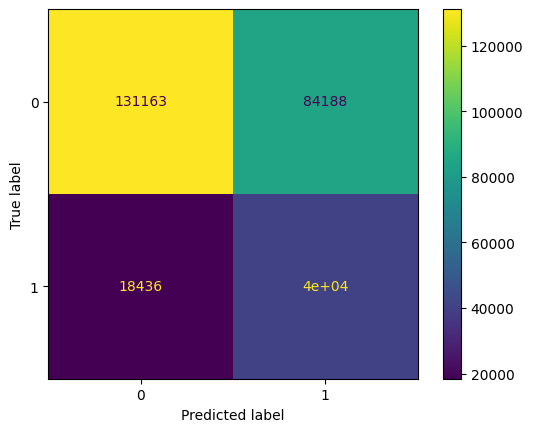

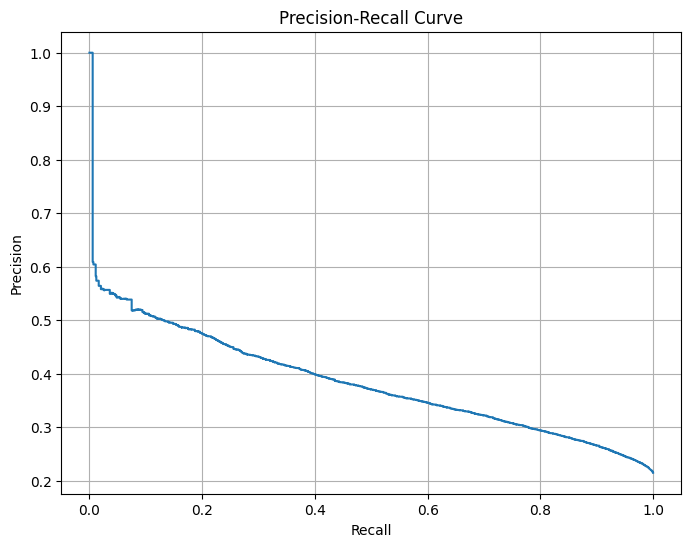

In [73]:
recall_train = recall_score(y_train_numeric, y_train_pred)
print(f"Recall (Train): {recall_train}")

recall_val = recall_score(y_test_numeric, y_test_pred)
print(f"Recall (Validation): {recall_val}")

precision_train = precision_score(y_train_numeric, y_train_pred)
print(f"Precision (Train): {precision_train}")

precision_val = precision_score(y_test_numeric, y_test_pred)
print(f"Precision (Validation): {precision_val}")

fbeta_train = fbeta_score(y_train_numeric, y_train_pred, beta=2)
print(f"F-Beta (Train): {fbeta_train}")

fbeta_val = fbeta_score(y_test_numeric, y_test_pred, beta=2)
print(f"F-Beta (Validation): {fbeta_val}")

matrix = confusion_matrix(y_test_numeric, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()

fig, ax = plt.subplots(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test_numeric, y_pred_prob[:,1])
lab = 'Overall AUC=%.4f'
ax.step(recall, precision, label=lab)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.grid(True)

## Model Explainability (SHAP)

SHAP values are a method that can explain the way predictions of machine learning models are built. SHAP values allocate the
contribution of each feature to the model’s output using a simple additive formula.
Important for establishing machine learning models’ overall interpretability and trustworthiness

In [74]:
from xgboost import DMatrix

In [75]:
booster = final_pipeline['xgboost_model'].get_booster()

Xt = final_pipeline[0:3].transform(X_train_subset)

feature_names = (
    final_pipeline[0:3].get_feature_names_out()
)

Xd = DMatrix(Xt)

shap_values = booster.predict(Xd, pred_contribs=True)
preds = booster.predict(Xd)

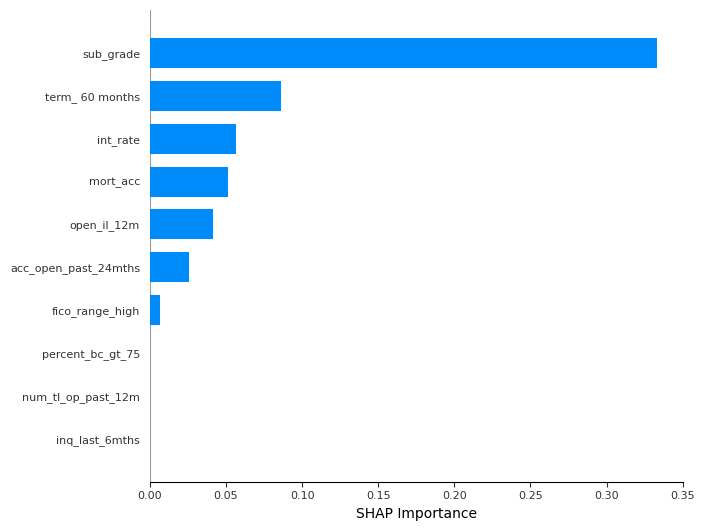

In [76]:
shap.summary_plot(
    shap_values[:,:-1],
    Xt,
    plot_type="bar",
    feature_names=feature_names,
    max_display=10,
    show=False
) 
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel("SHAP Importance", fontsize=10)
plt.show()

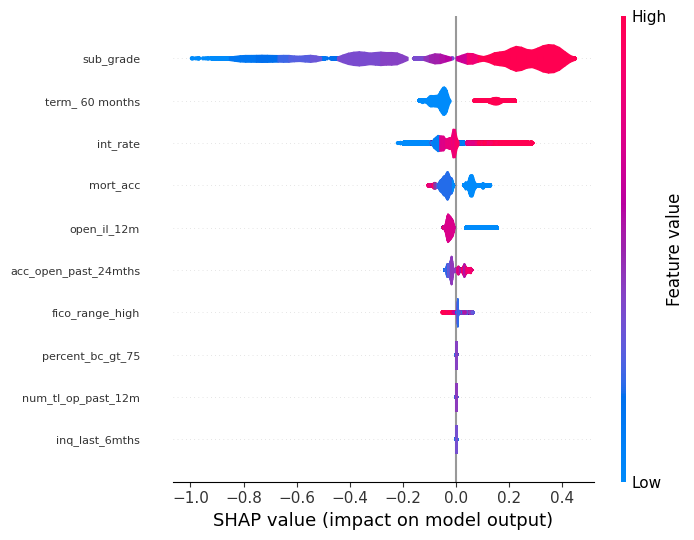

In [77]:
shap.summary_plot(shap_values[:,:-1], Xt,
    plot_type="violin",
    feature_names=feature_names,
    show=False) 
plt.yticks(fontsize=8)
plt.show()